<a href="https://colab.research.google.com/github/amitpaul05/Journey-to-AI/blob/master/CNN_in_PU_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_dir = '/content/drive/MyDrive/processed_dataset/train'
test_dir = '/content/drive/MyDrive/processed_dataset/test'

# VGG 16

In [ ]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [ ]:
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


In [ ]:
conv_base.trainable = True

set_trainable = False

for layer in conv_base.layers:
  if layer.name == 'block4_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False

for layer in conv_base.layers:
  print(layer.name,layer.trainable)

input_layer_4 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 True
block4_conv2 True
block4_conv3 True
block4_pool True
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [ ]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 12,979,200 (49.51 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

In [ ]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(3, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,243 (80.64 MB)

 Trainable params: 19,402,755 (74.02 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    directory=train_dir,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224, 224)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory=test_dir,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224, 224)
)


Found 1663 files belonging to 3 classes.
Found 416 files belonging to 3 classes.


In [ ]:
# Normalize
def process(image,label):
    image = tensorflow.cast(image/255. ,tensorflow.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
  )

In [ ]:
history = model.fit(train_ds,epochs=50,validation_data=validation_ds)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 319ms/step - accuracy: 0.4910 - loss: 0.9987 - val_accuracy: 0.4928 - val_loss: 0.9708
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 269ms/step - accuracy: 0.7161 - loss: 0.6642 - val_accuracy: 0.7620 - val_loss: 0.5539
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 275ms/step - accuracy: 0.8112 - loss: 0.4209 - val_accuracy: 0.9183 - val_loss: 0.2244
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 280ms/step - accuracy: 0.8969 - loss: 0.2656 - val_accuracy: 0.9351 - val_loss: 0.2089
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 285ms/step - accuracy: 0.9090 - loss: 0.2305 - val_accuracy: 0.9663 - val_loss: 0.1056
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 287ms/step - accuracy: 0.9461 - loss: 0.1490 - val_accuracy: 0.9615 - val_loss: 0.0985
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 287ms/step - accuracy: 0.9598 - loss: 0.1135 - val_accuracy: 0.9303 - val_loss: 0.2052
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 289ms/step - accuracy: 0.9542 - loss: 0.1266 - val_accu

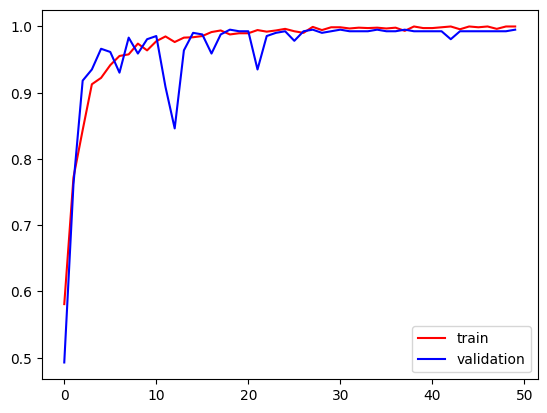

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

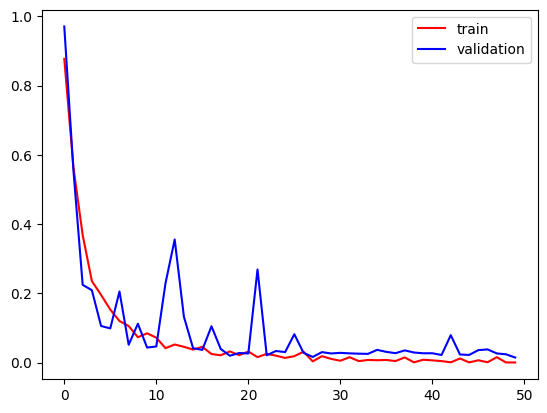

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf

# Collect predictions and labels
all_predictions = []
all_labels = []

for images, labels in validation_ds:
    predictions = model.predict(images, verbose=0)
    all_predictions.append(predictions)
    all_labels.append(labels.numpy())

# Combine all batches
all_predictions = np.concatenate(all_predictions, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# --- Define your class names ---
# Change this list to match your dataset
class_names = ['Healthy', 'Diseased', 'Other']

# Compute average predicted probability for each class
average_predictions = np.mean(all_predictions, axis=0) * 100

# Display average class prediction percentages
print("Average prediction percentage across all validation images:\n")
for i, percentage in enumerate(average_predictions):
    print(f"Class {i} ({class_names[i]}): {percentage:.2f}%")


Average prediction percentage across all validation images:

Class 0 (Healthy): 23.56%
Class 1 (Diseased): 34.12%
Class 2 (Other): 42.32%


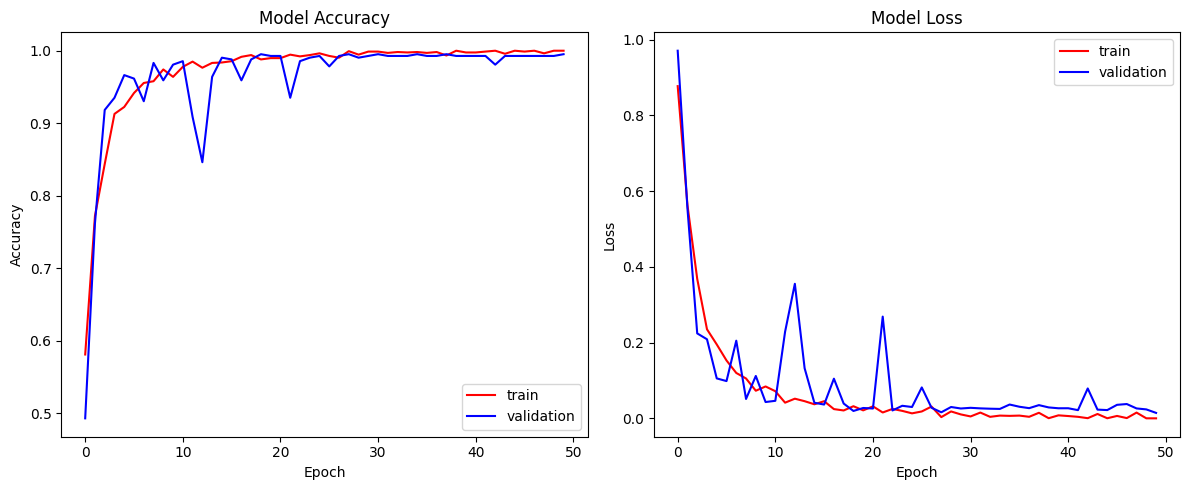

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
!ls /content/drive/MyDrive/processed_dataset/train

healthy  inner	outer


In [ ]:
import numpy as np
import tensorflow as tf

all_predictions = []
all_labels = []

# Iterate through entire validation dataset
for images, labels in validation_ds:
    predictions = model.predict(images, verbose=0)
    all_predictions.append(predictions)
    all_labels.append(labels.numpy())

# Combine all batches
all_predictions = np.concatenate(all_predictions, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Define your class names from the dataset
class_names = ['healthy', 'inner', 'outer']

# Compute the average prediction percentage for each class
average_predictions = np.mean(all_predictions, axis=0) * 100

# Display the overall prediction percentages
print("Average prediction percentage across all validation images:\n")
for i, percentage in enumerate(average_predictions):
    print(f"Class {i} ({class_names[i]}): {percentage:.2f}%")


Average prediction percentage across all validation images:

Class 0 (healthy): 23.56%
Class 1 (inner): 34.12%
Class 2 (outer): 42.32%


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

predicted_classes = np.argmax(all_predictions, axis=1)

# Confusion matrix
cm = confusion_matrix(all_labels, predicted_classes)
print("Confusion Matrix:\n", cm)

# Per-class accuracy
class_names = ['healthy', 'inner', 'outer']
class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("\nPer-class accuracy:")
for name, acc in zip(class_names, class_accuracy):
    print(f"{name}: {acc * 100:.2f}%")


Confusion Matrix:
 [[ 96   0   0]
 [  2 142   0]
 [  0   0 176]]

Per-class accuracy:
healthy: 100.00%
inner: 98.61%
outer: 100.00%


Confusion Matrix (values):
 [[ 96   0   0]
 [  2 142   0]
 [  0   0 176]]

Per-class accuracy:
healthy: 100.00%
inner: 98.61%
outer: 100.00%


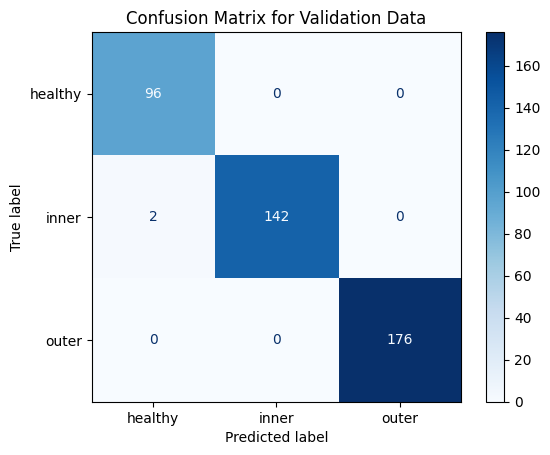

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Use your existing predictions ---
predicted_classes = np.argmax(all_predictions, axis=1)
true_classes = all_labels

# --- Define class names ---
class_names = ['healthy', 'inner', 'outer']

# --- Compute confusion matrix ---
cm = confusion_matrix(true_classes, predicted_classes)

# --- Display as text ---
print("Confusion Matrix (values):\n", cm)

# --- Optional: Calculate per-class accuracy ---
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class accuracy:")
for name, acc in zip(class_names, per_class_accuracy):
    print(f"{name}: {acc * 100:.2f}%")

# --- Visualize confusion matrix ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Validation Data")
plt.show()


# VGG 16 feature extraction

In [ ]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [ ]:
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
conv_base.trainable = False

In [ ]:
for layer in conv_base.layers:
  print(layer.name,layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 False
block5_conv2 False
block5_conv3 False
block5_pool False


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [ ]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = train_dir,
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(224,224)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = test_dir,
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(224,224)
)

Found 1663 files belonging to 3 classes.
Found 416 files belonging to 3 classes.


In [ ]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(3, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,243 (80.64 MB)

 Trainable params: 6,423,555 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
  )

In [ ]:
history = model.fit(train_ds,epochs=50,validation_data=validation_ds)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 358s 7s/step - accuracy: 0.4185 - loss: 2.0661 - val_accuracy: 0.6779 - val_loss: 0.8143
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 226ms/step - accuracy: 0.7061 - loss: 0.7736 - val_accuracy: 0.7885 - val_loss: 0.5300
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 226ms/step - accuracy: 0.8079 - loss: 0.4810 - val_accuracy: 0.8197 - val_loss: 0.3984
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 217ms/step - accuracy: 0.8738 - loss: 0.3512 - val_accuracy: 0.8654 - val_loss: 0.3052
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 214ms/step - accuracy: 0.9042 - loss: 0.2533 - val_accuracy: 0.8341 - val_loss: 0.3813
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - accuracy: 0.9133 - loss: 0.2216 - val_accuracy: 0.9111 - val_loss: 0.2135
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - accuracy: 0.9350 - loss: 0.1798 - val_accuracy: 0.9159 - val_loss: 0.1947
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 218ms/step - accuracy: 0.9517 - loss: 0.1260 - val_accura

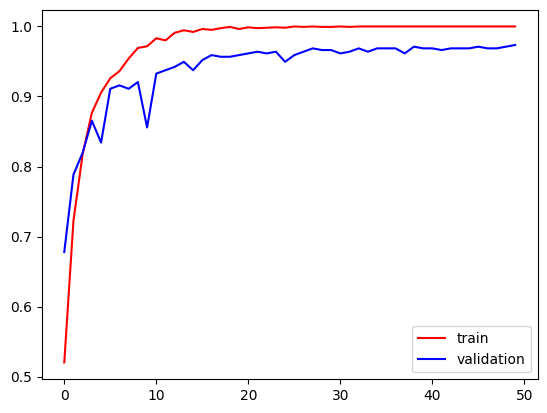

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

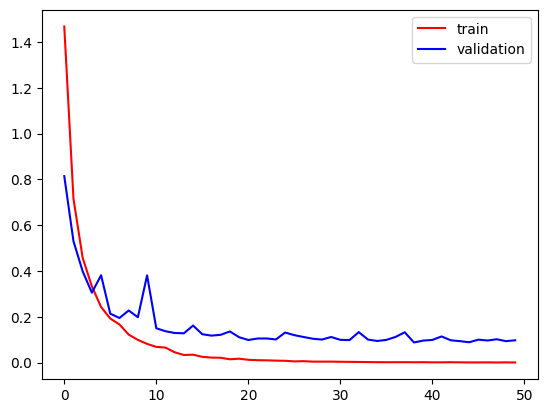

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf

# Collect predictions and labels
all_predictions = []
all_labels = []

for images, labels in validation_ds:
    predictions = model.predict(images, verbose=0)
    all_predictions.append(predictions)
    all_labels.append(labels.numpy())

# Combine all batches
all_predictions = np.concatenate(all_predictions, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# --- Define your class names ---
# Change this list to match your dataset
class_names = ['Healthy', 'Diseased', 'Other']

# Compute average predicted probability for each class
average_predictions = np.mean(all_predictions, axis=0) * 100

# Display average class prediction percentages
print("Average prediction percentage across all validation images:\n")
for i, percentage in enumerate(average_predictions):
    print(f"Class {i} ({class_names[i]}): {percentage:.2f}%")

Average prediction percentage across all validation images:

Class 0 (Healthy): 23.18%
Class 1 (Diseased): 34.72%
Class 2 (Other): 42.10%


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

predicted_classes = np.argmax(all_predictions, axis=1)

# Confusion matrix
cm = confusion_matrix(all_labels, predicted_classes)
print("Confusion Matrix:\n", cm)

# Per-class accuracy
class_names = ['healthy', 'inner', 'outer']
class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("\nPer-class accuracy:")
for name, acc in zip(class_names, class_accuracy):
    print(f"{name}: {acc * 100:.2f}%")

Confusion Matrix:
 [[ 91   5   0]
 [  5 139   0]
 [  0   1 175]]

Per-class accuracy:
healthy: 94.79%
inner: 96.53%
outer: 99.43%


Confusion Matrix (values):
 [[ 91   5   0]
 [  5 139   0]
 [  0   1 175]]

Per-class accuracy:
healthy: 94.79%
inner: 96.53%
outer: 99.43%


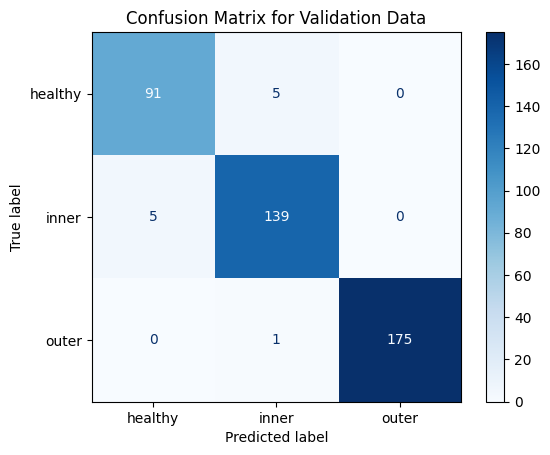

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Use your existing predictions ---
predicted_classes = np.argmax(all_predictions, axis=1)
true_classes = all_labels

# --- Define class names ---
class_names = ['healthy', 'inner', 'outer']

# --- Compute confusion matrix ---
cm = confusion_matrix(true_classes, predicted_classes)

# --- Display as text ---
print("Confusion Matrix (values):\n", cm)

# --- Optional: Calculate per-class accuracy ---
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class accuracy:")
for name, acc in zip(class_names, per_class_accuracy):
    print(f"{name}: {acc * 100:.2f}%")

# --- Visualize confusion matrix ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Validation Data")
plt.show()

In [ ]:
from sklearn.metrics import f1_score, classification_report

# --- F1 Score (per class and overall) ---
f1_per_class = f1_score(true_classes, predicted_classes, average=None)
f1_macro = f1_score(true_classes, predicted_classes, average='macro')
f1_weighted = f1_score(true_classes, predicted_classes, average='weighted')

print("\nF1 Score per class:")
for name, f1 in zip(class_names, f1_per_class):
    print(f"{name}: {f1:.4f}")

print(f"\nMacro F1 Score: {f1_macro:.4f}")
print(f"Weighted F1 Score: {f1_weighted:.4f}")

# --- Detailed Classification Report ---
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_names))



F1 Score per class:
healthy: 0.9479
inner: 0.9619
outer: 0.9972

Macro F1 Score: 0.9690
Weighted F1 Score: 0.9736

Classification Report:
              precision    recall  f1-score   support

     healthy       0.95      0.95      0.95        96
       inner       0.96      0.97      0.96       144
       outer       1.00      0.99      1.00       176

    accuracy                           0.97       416
   macro avg       0.97      0.97      0.97       416
weighted avg       0.97      0.97      0.97       416



# Resnet50

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten
from keras.applications.resnet50 import ResNet50

In [ ]:
conv_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [ ]:
conv_base.trainable = True

# Set all layers frozen by default
for layer in conv_base.layers:
    layer.trainable = False

# Enable only conv3, conv4, conv5 blocks
for layer in conv_base.layers:
    if layer.name.startswith("conv3_") or \
       layer.name.startswith("conv4_") or \
       layer.name.startswith("conv5_"):

        layer.trainable = True

# Print layer/trainable status
for layer in conv_base.layers:
    print(layer.name, layer.trainable)

conv_base.summary()

input_layer_2 False
conv1_pad False
conv1_conv False
conv1_bn False
conv1_relu False
pool1_pad False
pool1_pool False
conv2_block1_1_conv False
conv2_block1_1_bn False
conv2_block1_1_relu False
conv2_block1_2_conv False
conv2_block1_2_bn False
conv2_block1_2_relu False
conv2_block1_0_conv False
conv2_block1_3_conv False
conv2_block1_0_bn False
conv2_block1_3_bn False
conv2_block1_add False
conv2_block1_out False
conv2_block2_1_conv False
conv2_block2_1_bn False
conv2_block2_1_relu False
conv2_block2_2_conv False
conv2_block2_2_bn False
conv2_block2_2_relu False
conv2_block2_3_conv False
conv2_block2_3_bn False
conv2_block2_add False
conv2_block2_out False
conv2_block3_1_conv False
conv2_block3_1_bn False
conv2_block3_1_relu False
conv2_block3_2_conv False
conv2_block3_2_bn False
conv2_block3_2_relu False
conv2_block3_3_conv False
conv2_block3_3_bn False
conv2_block3_add False
conv2_block3_out False
conv3_block1_1_conv True
conv3_block1_1_bn True
conv3_block1_1_relu True
conv3_block1_2_

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,307,776 (88.91 MB)

 Non-trainable params: 279,936 (1.07 MB)

In [ ]:
model = Sequential()
model.add(conv_base)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(3, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,278,851 (187.98 MB)

 Trainable params: 48,998,915 (186.92 MB)

 Non-trainable params: 279,936 (1.07 MB)

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    directory=train_dir,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224, 224)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory=test_dir,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224, 224)
)

Found 1663 files belonging to 3 classes.
Found 416 files belonging to 3 classes.


In [ ]:
def process(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=validation_ds
)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 63s 570ms/step - accuracy: 0.9989 - loss: 0.0033 - val_accuracy: 0.9567 - val_loss: 0.1509
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 51s 245ms/step - accuracy: 1.0000 - loss: 4.6544e-04 - val_accuracy: 0.9423 - val_loss: 0.1721
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 253ms/step - accuracy: 1.0000 - loss: 1.7924e-05 - val_accuracy: 0.9736 - val_loss: 0.0820
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 256ms/step - accuracy: 1.0000 - loss: 4.4763e-06 - val_accuracy: 0.9976 - val_loss: 0.0038
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 256ms/step - accuracy: 0.9983 - loss: 0.0050 - val_accuracy: 0.9904 - val_loss: 0.0260
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 248ms/step - accuracy: 1.0000 - loss: 1.8664e-04 - val_accuracy: 0.9952 - val_loss: 0.0191
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 264ms/step - accuracy: 0.9999 - loss: 1.5074e-04 - val_accuracy: 0.6923 - val_loss: 1.7025
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 244ms/step - accuracy: 0.9969 - los